C:\Users\frlja\AppData\Local\Temp\ipykernel_18060\2996172379.py:19: UserWarning: 'has_mps' is deprecated, please use 'torch.backends.mps.is_built()'
  elif (torch.has_mps or torch.backends.mps.is_available()) and ALLOW_MPS:


Using device: cpu


100%|██████████| 25/25 [03:56<00:00,  9.45s/it]


Afbeelding opgeslagen als: ../images\output_48.jpg


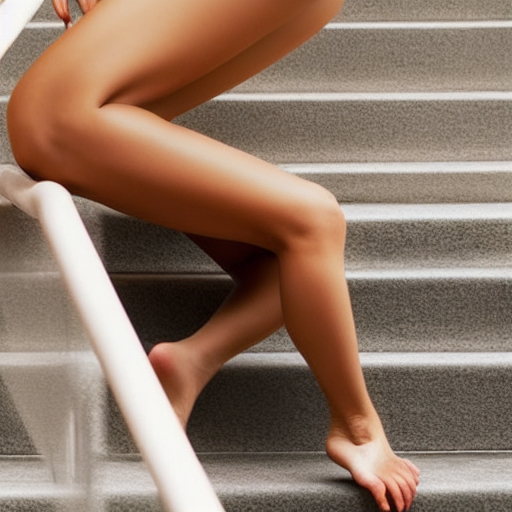

In [2]:
import model_loader
import pipeline
from PIL import Image
from pathlib import Path
from transformers import CLIPTokenizer
import torch
import os

# Pad naar de map
folder = "../images"

DEVICE = "cpu"

ALLOW_CUDA = True
ALLOW_MPS = False

if torch.cuda.is_available() and ALLOW_CUDA:
    DEVICE = "cuda"
elif (torch.has_mps or torch.backends.mps.is_available()) and ALLOW_MPS:
    DEVICE = "mps"
print(f"Using device: {DEVICE}")

tokenizer = CLIPTokenizer("../data/vocab.json", merges_file="../data/merges.txt")
model_file = "../data/v1-5-pruned-emaonly.ckpt"
models = model_loader.preload_models_from_standard_weights(model_file, DEVICE)

## TEXT TO IMAGE

prompt = "Naked woman sliding down railing of stairs"
# prompt = "A cat stretching on the floor, highly detailed, ultra sharp, cinematic, 100mm lens, 8k resolution."
uncond_prompt = ""  # Also known as negative prompt what we don't want to see in the image
do_cfg = True
cfg_scale = 12  # min: 1, max: 14

## IMAGE TO IMAGE

# Uncomment to disable image to image

input_image = None

image_path = "../images/output_17.jpg"

# Comment to disable image to image
# input_image = Image.open(image_path)

# Higher values means more noise will be added to the input image, so the result will further from the input image.
# Lower values means less noise is added to the input image, so output will be closer to the input image.
strength = 0.9

## SAMPLER

sampler = "ddpm"
num_inference_steps = 25
seed = None

output_image = pipeline.generate(
    prompt=prompt,
    uncond_prompt=uncond_prompt,
    input_image=input_image,
    strength=strength,
    do_cfg=do_cfg,
    cfg_scale=cfg_scale,
    sampler_name=sampler,
    n_inference_steps=num_inference_steps,
    seed=seed,
    models=models,
    device=DEVICE,
    idle_device="cpu",
    tokenizer=tokenizer,
)

# Combine the input image and the output image into a single image.
final_image = Image.fromarray(output_image)

# Tel hoeveel bestanden er al in de map staan
n = len([f for f in os.listdir(folder) if os.path.isfile(os.path.join(folder, f))])

# Maak een nieuwe bestandsnaam
save_path = os.path.join(folder, f"output_{n}.jpg")

# Sla de afbeelding op
final_image.save(save_path)

print(f"Afbeelding opgeslagen als: {save_path}")

# Inline tonen in Jupyter
display(final_image)